In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import sklearn.metrics as metrics
import igraph as ig
import random as random
from GmGM import GmGM, Dataset
from MED_MAGMA import fast_kronecker_sum_model, quotient, EM_algorithm, sparse_quotient
import scanpy as sc
import anndata as ad
import pandas as pd
from scipy import stats
from gprofiler import GProfiler
ad.settings.allow_write_nullable_strings = True # sc.datasets.ebi_expression_atlas crashes if false

%load_ext line_profiler
%load_ext autoreload
%autoreload 2

## Load all results and find the median by MED-MAGMA assortativity.

In [2]:
results = pd.read_csv("results/all-datasets-less-than-1000-cells-results-all.csv")
results

,Unnamed: 0,assortativity,ami,ami_resolution,ari,ari_resolution,sparsity,num_genes_kept,num_cells,num_em_iterations,num_categories,dataset_name,truth_class_name,source_url,paper_url,reported_cell_count,reported_truth_class
0,EM,0.616162,0.706349,0.58,0.812264,0.58,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
1,GmGM,0.884116,1.000000,0.30,1.000000,0.30,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
2,GmGM+nonpara,0.884116,1.000000,0.30,1.000000,0.30,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
3,Basic,0.884116,0.254212,1.10,0.141804,0.04,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
4,EM,0.046149,0.538151,1.04,0.413860,0.82,0.992102,91,96,20,3,E-MTAB-6142,Sample Characteristic[cell cycle phase],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/29045817,96,cell cycle phase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Basic,0.002151,0.130927,1.96,0.063778,0.36,0.963648,324,329,20,4,E-GEOD-109979,Factor Value[time],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/29427839,329,none advertised
116,EM,-0.074122,0.062703,0.74,0.022181,0.86,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised
117,GmGM,0.045973,0.133531,0.86,0.042187,0.86,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised
118,GmGM+nonpara,0.012460,0.132263,0.76,0.040755,0.72,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised


In [4]:
# There are 30 datasets; numbering them 0 to 29, the median could either be #14 or #15 - we chose #15
# TODO - results changed but we should still be #14 by absolute assortativity...
median_df = results[results["Unnamed: 0"]=="EM"].sort_values(by="assortativity").iloc[15:16]
median_df

,Unnamed: 0,assortativity,ami,ami_resolution,ari,ari_resolution,sparsity,num_genes_kept,num_cells,num_em_iterations,num_categories,dataset_name,truth_class_name,source_url,paper_url,reported_cell_count,reported_truth_class
24,EM,0.274372,0.577335,0.76,0.487025,0.76,0.707465,185,185,20,7,E-MTAB-7249,Sample Characteristic[inferred cell type - aut...,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/32054838,192,inferred cell type - authors labels


In [5]:
median_df[["dataset_name", "num_cells", "num_genes_kept", "paper_url"]].iloc[0]

dataset_name                                     E-MTAB-7249
num_cells                                                185
num_genes_kept                                           185
paper_url         https://europepmc.org/article/MED/32054838
Name: 24, dtype: object

In [346]:
true_clusters = median_df["truth_class_name"].iloc[0]
true_clusters

'Sample Characteristic[inferred cell type - authors labels]'

In [347]:
median_df["source_url"].iloc[0]

'https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-7249/results/cell-plots'

## Load the median, pre-process, and run MED-MAGMA on it.

In [348]:
adata = sc.datasets.ebi_expression_atlas("E-MTAB-7249")
raw_data = adata.X.copy()

sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.var["num_cells"] = np.asarray(np.sum(adata.X > 0, axis=0)).ravel()

# Loop through like before but stop once we reach the number of genes we know we had
for percent in np.linspace(0, 1, 101):
    cur_chosen_genes = (
        (adata.var["num_cells"].to_numpy() > percent * adata.shape[0])
        & adata.var["highly_variable"].to_numpy()
    )
    cur_num_genes = cur_chosen_genes.sum()
    if (cur_num_genes == median_df["num_genes_kept"].iloc[0]):
        break
else:
    raise Exception("Should have been able to get have right number of genes, but could not...")

chosen_genes = cur_chosen_genes

# Restrict the data to chosen genes
for_input = raw_data[:, chosen_genes].toarray()
adata = adata[:, chosen_genes]

adata

View of AnnData object with n_obs × n_vars = 185 × 185
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[tumor grading]', 'Sample Characteristic Ontology Term[tumor grading]', 'Sample Characteristic[disease staging]', 'Sample Characteristic Ontology Term[disease staging]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[cell type]', 'Sample Characteristic Ontology Term[cell type]', 'Sample Characteristic[inferred cell type - authors labels]', 'Sample Characteristic Ontology Term[inferred cell type - authors labels]', 'Factor Value[inferred c

In [349]:
# Get patient name
adata.obs['Sample Characteristic[individual]'].value_counts()

Sample Characteristic[individual]
OCM.38    185
Name: count, dtype: int64

In [396]:
def keep_top_k_per_row(matrix, k):
        new_matrix = np.zeros_like(matrix)
        for i in range(matrix.shape[0]):
            row = matrix[i]
            top_k_indices = np.argsort(row)[-k:]
            new_matrix[i, top_k_indices] = row[top_k_indices]
        # re-symmetrize
        new_matrix += new_matrix.T
        return new_matrix

# Our robust method
np.random.seed(0)
EM_results, magnitudes = EM_algorithm(
    sparse_quotient(for_input),
    max_iter=20,
    stop_tol=1e-7,
    return_s_values=False,
    very_verbose=True
)

# Attach results to adata
cell_graph_em = np.abs(EM_results[0])
np.fill_diagonal(cell_graph_em, 0)
gene_graph_em = np.abs(EM_results[1])
np.fill_diagonal(cell_graph_em, 0)
adata.obsp["EM_cell_graph"] = keep_top_k_per_row(cell_graph_em, 10)
adata.varp["EM_gene_graph"] = keep_top_k_per_row(gene_graph_em, 10)

Beginning iteration 0 
Beginning iteration 1 with magnitude 7.0e+02
Beginning iteration 2 with magnitude 6.9e+02
Beginning iteration 3 with magnitude 1.3e+01
Beginning iteration 4 with magnitude 1.2e+01
Beginning iteration 5 with magnitude 1.1e+01
Beginning iteration 6 with magnitude 3.7e+00
Beginning iteration 7 with magnitude 3.7e-01
Beginning iteration 8 with magnitude 1.5e+00
Beginning iteration 9 with magnitude 6.1e-01
Beginning iteration 10 with magnitude 1.3e-01
Beginning iteration 11 with magnitude 1.2e-01
Beginning iteration 12 with magnitude 1.9e-01
Beginning iteration 13 with magnitude 5.8e-02
Beginning iteration 14 with magnitude 1.1e-02
Beginning iteration 15 with magnitude 1.3e+00
Beginning iteration 16 with magnitude 9.9e-01
Beginning iteration 17 with magnitude 5.1e-01
Beginning iteration 18 with magnitude 1.1e+00
Beginning iteration 19 with magnitude 1.4e+00


In [397]:
# Re-create cell clusters
sc.tl.leiden(adata, key_added="leiden_EM", adjacency=adata.obsp["EM_cell_graph"], flavor="igraph", resolution=median_df["ami_resolution"].iloc[0])

# Create gene clusters as well at the default resolution
bdata = adata.transpose()
sc.tl.leiden(bdata, key_added="leiden_EM", adjacency=bdata.obsp["EM_gene_graph"], flavor="igraph", resolution=1)
adata.var["leiden_EM"] = bdata.obs["leiden_EM"]

adata

AnnData object with n_obs × n_vars = 185 × 185
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[tumor grading]', 'Sample Characteristic Ontology Term[tumor grading]', 'Sample Characteristic[disease staging]', 'Sample Characteristic Ontology Term[disease staging]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[cell type]', 'Sample Characteristic Ontology Term[cell type]', 'Sample Characteristic[inferred cell type - authors labels]', 'Sample Characteristic Ontology Term[inferred cell type - authors labels]', 'Factor Value[inferred cell type

In [398]:
adata.var["leiden_EM"].value_counts()

leiden_EM
0    46
6    45
3    33
4    20
5    16
2    15
1    10
Name: count, dtype: int64

In [399]:
adata.obs[true_clusters].value_counts()

Sample Characteristic[inferred cell type - authors labels]
TA-a             47
SA-a             42
TA-b             40
SA-b             22
SB               21
not available     7
TB                6
Name: count, dtype: int64

## Explore how well the gene clustering interacts with the labels

In [400]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

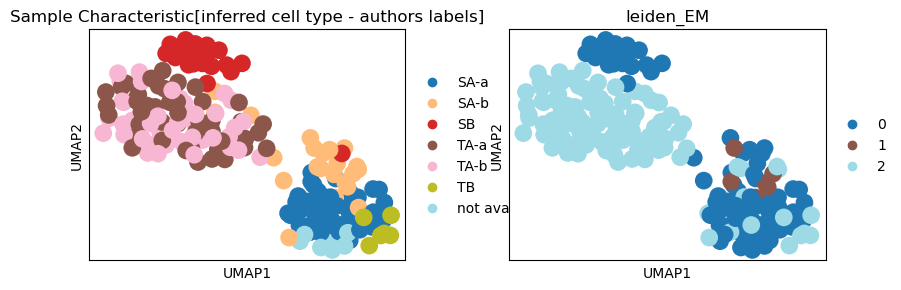

In [401]:
sc.pl.umap(adata, color=[true_clusters, "leiden_EM"], palette='tab20')

In [402]:
# Get the median expression of various genes
for gene_module in adata.var["leiden_EM"].unique():
    in_module_expression = for_input[:, adata.var["leiden_EM"] == gene_module].sum(axis=1)
    all_expression = for_input.sum(axis=1)
    adata.obs[f"m{gene_module}_percent"] = in_module_expression / all_expression
adata

AnnData object with n_obs × n_vars = 185 × 185
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[tumor grading]', 'Sample Characteristic Ontology Term[tumor grading]', 'Sample Characteristic[disease staging]', 'Sample Characteristic Ontology Term[disease staging]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[cell type]', 'Sample Characteristic Ontology Term[cell type]', 'Sample Characteristic[inferred cell type - authors labels]', 'Sample Characteristic Ontology Term[inferred cell type - authors labels]', 'Factor Value[inferred cell type

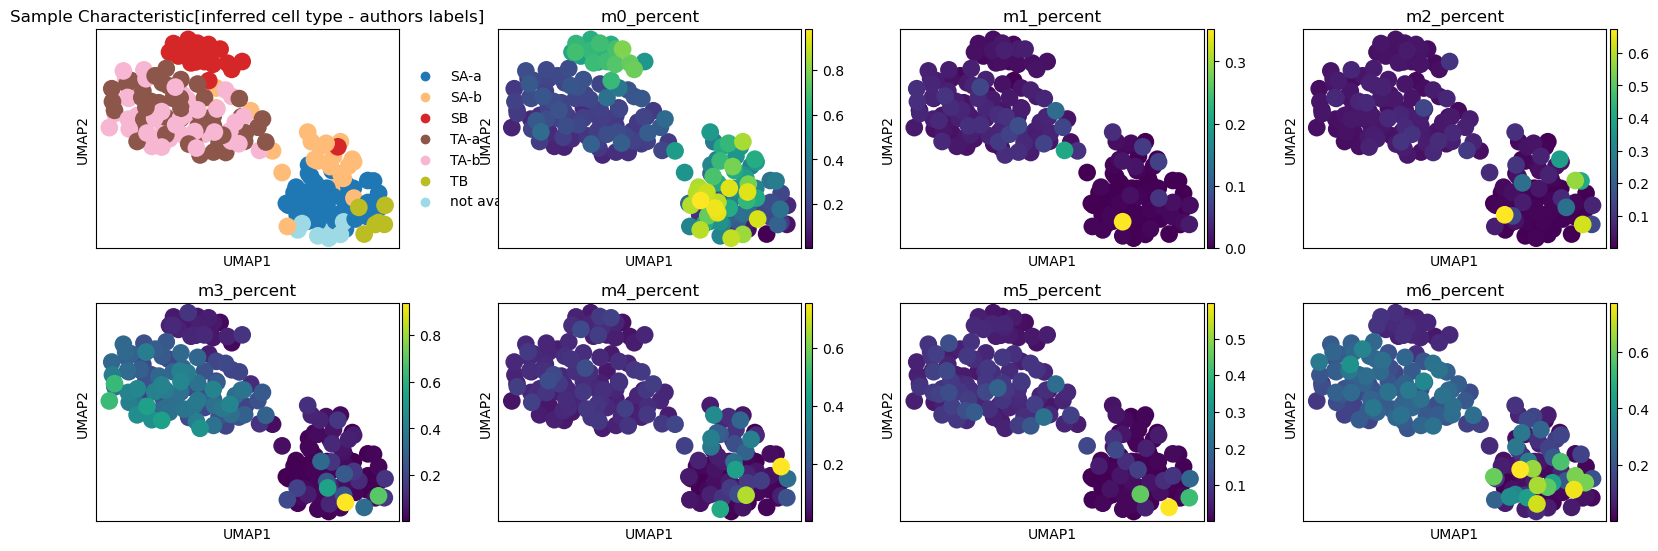

In [403]:
sc.pl.umap(adata, color=[true_clusters] + [f"m{g}_percent" for g in adata.var["leiden_EM"].unique()], palette='tab20')

In [404]:
for g in adata.var["leiden_EM"].unique():
    groups = adata.obs.groupby(true_clusters)[f"m{g}_percent"]
    print(f"Module m{g}: {stats.f_oneway(*[g.values for _, g in groups])}")

Module m0: F_onewayResult(statistic=np.float32(38.07799), pvalue=np.float32(1.5973822e-29))
Module m1: F_onewayResult(statistic=np.float32(3.3956969), pvalue=np.float32(0.003391796))
Module m2: F_onewayResult(statistic=np.float32(2.8728766), pvalue=np.float32(0.010719816))
Module m3: F_onewayResult(statistic=np.float32(30.894533), pvalue=np.float32(2.8412204e-25))
Module m4: F_onewayResult(statistic=np.float32(1.80347), pvalue=np.float32(0.10079666))
Module m5: F_onewayResult(statistic=np.float32(11.206461), pvalue=np.float32(1.3421174e-10))
Module m6: F_onewayResult(statistic=np.float32(4.154544), pvalue=np.float32(0.0006217479))


Great - we can see that gene modules line up well with cell types (except m7).  Below, we can also see that they line up well with our MED-MAGMA clusters (except m3, m5)

In [414]:
for g in adata.var["leiden_EM"].unique():
    groups = adata.obs.groupby("leiden_EM")[f"m{g}_percent"]
    print(f"Module m{g}: {stats.f_oneway(*[g.values for _, g in groups])}")

Module m0: F_onewayResult(statistic=np.float32(97.19822), pvalue=np.float32(1.917588e-29))
Module m1: F_onewayResult(statistic=np.float32(6.8485923), pvalue=np.float32(0.0013561251))
Module m2: F_onewayResult(statistic=np.float32(0.34921065), pvalue=np.float32(0.7057161))
Module m3: F_onewayResult(statistic=np.float32(69.54676), pvalue=np.float32(3.656166e-23))
Module m4: F_onewayResult(statistic=np.float32(11.865106), pvalue=np.float32(1.4334144e-05))
Module m5: F_onewayResult(statistic=np.float32(14.104238), pvalue=np.float32(2.0198827e-06))
Module m6: F_onewayResult(statistic=np.float32(4.5691996), pvalue=np.float32(0.011583328))


## Look at what happens when we investigate full cell types

In [415]:
adata.obs['cell type'] = 'unknown'
adata.obs.loc[adata.obs[true_clusters].str.startswith('T'), 'cell type'] = 'neoplastic'
adata.obs.loc[adata.obs[true_clusters].str.startswith('S'), 'cell type'] = 'stromal'
adata.obs['cell type'] = adata.obs['cell type'].astype('category')
adata.obs['cell type'].value_counts()

cell type
neoplastic    93
stromal       85
unknown        7
Name: count, dtype: int64

In [431]:
for g in adata.var['leiden_EM'].unique():
    adata.obs[f'm{g}_cutoff'] = (adata.obs[f'm{g}_percent'] > 0.3) * 1

/Users/baileyandrew/mambaforge/envs/TED-MAGMA/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


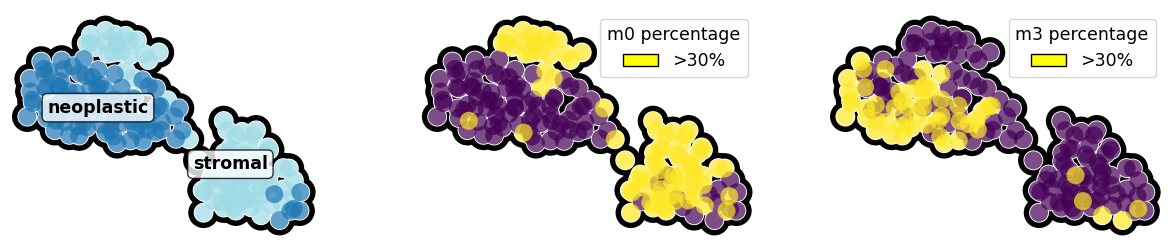

In [433]:
# Making scanpy's umap figures actually work is so annoying... it is very hard to tweak plot params robustly

original_figsize = plt.rcParams['figure.figsize']
plt.rcParams['figure.figsize'] = (4, 3)
axs = sc.pl.umap(
    adata[adata.obs['cell type'] != 'unknown'],
    color=['cell type', 'm0_cutoff', 'm3_cutoff'],
    palette='tab20',
    legend_loc='on data',
    frameon=False,
    add_outline=True,
    show=False,
    colorbar_loc=None
)
plt.rcParams['figure.figsize'] = original_figsize
fig = axs[0].get_figure()
for idx, ax in enumerate(axs):
    ax.set_title("", fontsize=16)

    # Fix slight cutoff that happens
    down_xlim, up_xlim = ax.get_xlim()
    ax.set_xlim(down_xlim-0.1, up_xlim+0.1)
    down_ylim, up_ylim = ax.get_ylim()
    ax.set_ylim(down_ylim-0.5, up_ylim+0.5)
    
    for t in ax.texts:
        t.set_fontsize(12.5)
        t.set_bbox(dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8))

    # Add a legend with patches
    if idx > 0:
        handles = [mpatches.Patch(facecolor="yellow", edgecolor='black', label=">30%")]
        ax.legend(handles=handles, title=f"m{0 if idx==1 else 3} percentage", fontsize=12.5, title_fontsize=12.5)

# # Colorbars
# for cax in fig.axes:
#     if getattr(cax, "get_label", lambda: "")() == "<colorbar>":
#         for t in cax.get_yticklabels():  # y-axis labels of colorbar
#             t.set_fontsize(14)

fig.savefig("./figures/umap.pdf")

## Look at top genes in modules

Would like to look at GO terms, but there are too few genes in this dataset for such an analysis

In [434]:
centrality_genelists = []

for g in range(0, 8):
    module_network = adata[:, adata.var['leiden_EM'] == f"{g}"].varp['EM_gene_graph'] != 0

    # Genes sorted by degree centrality
    sorted_genes = adata[:, adata.var['leiden_EM'] == f"{g}"].var_names[module_network.sum(axis=0).argsort()[::-1]]
    centrality_genelists.append(sorted_genes)
    print(f"Top 3 genes in m{g}: {sorted_genes[:3]}")

Top 3 genes in m0: Index(['ENSG00000003436', 'ENSG00000150093', 'ENSG00000103196'], dtype='string')
Top 3 genes in m1: Index(['ENSG00000134897', 'ENSG00000134759', 'ENSG00000177646'], dtype='string')
Top 3 genes in m2: Index(['ENSG00000176871', 'ENSG00000163902', 'ENSG00000124155'], dtype='string')
Top 3 genes in m3: Index(['ENSG00000119335', 'ENSG00000075239', 'ENSG00000104375'], dtype='string')
Top 3 genes in m4: Index(['ENSG00000196305', 'ENSG00000047849', 'ENSG00000100934'], dtype='string')
Top 3 genes in m5: Index(['ENSG00000137831', 'ENSG00000165527', 'ENSG00000054267'], dtype='string')
Top 3 genes in m6: Index(['ENSG00000114503', 'ENSG00000114573', 'ENSG00000198380'], dtype='string')
Top 3 genes in m7: Index([], dtype='string')


## Do genes exhibit non-Gaussian-copula features such as tail dependence?

In [435]:
def tail_dependence(x, y, q=0.93):
    xq = np.quantile(x, q)
    yq = np.quantile(y, q)

    joint = np.sum((x > xq) & (y > yq))
    x_tail = np.sum(x > xq)

    return joint / x_tail

# Get two random genes:
np.random.seed(0)
num_trials = 1000
tail_dependencies = np.zeros(num_trials)
fake_tail_dependencies = np.zeros(num_trials)
for i in range(num_trials):
    g1 = np.random.randint(0, adata.shape[0])
    g2 = np.random.randint(0, adata.shape[0])
    x, y = adata[:, [g1, g2]].X.toarray().T

    # Transform to copula
    u = stats.rankdata(x) / (len(x)+1)
    v = stats.rankdata(y) / (len(y)+1)
    tail_dependencies[i] = tail_dependence(u, v)

    # Compare against truly random variables
    f1 = np.random.normal(size=adata.shape[0])
    f2 = np.random.normal(size=adata.shape[0])

    # Transform to copula
    u = stats.rankdata(f1) / (len(f1)+1)
    v = stats.rankdata(f2) / (len(f2)+1)
    fake_tail_dependencies[i] = tail_dependence(u, v)

# Get two random cells:
np.random.seed(0)
num_trials = 1000
cell_tail_dependencies = np.zeros(num_trials)
cell_fake_tail_dependencies = np.zeros(num_trials)
for i in range(num_trials):
    g1 = np.random.randint(0, adata.shape[1])
    g2 = np.random.randint(0, adata.shape[1])
    x, y = adata[[g1, g2], :].X.toarray()

    # Transform to copula
    u = stats.rankdata(x) / (len(x)+1)
    v = stats.rankdata(y) / (len(y)+1)
    cell_tail_dependencies[i] = tail_dependence(u, v)

    # Compare against truly random variables
    f1 = np.random.normal(size=adata.shape[1])
    f2 = np.random.normal(size=adata.shape[1])

    # Transform to copula
    u = stats.rankdata(f1) / (len(f1)+1)
    v = stats.rankdata(f2) / (len(f2)+1)
    cell_fake_tail_dependencies[i] = tail_dependence(u, v)

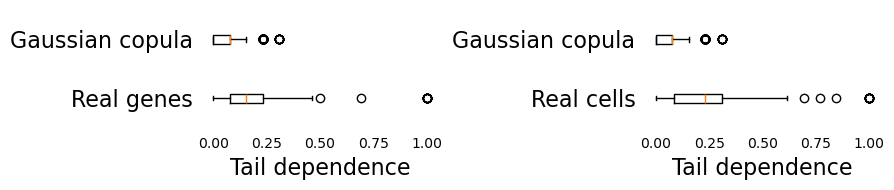

In [436]:
fig, (ax1, ax2) = plt.subplots(figsize=(9, 2), ncols=2)
ax1.boxplot([tail_dependencies, fake_tail_dependencies], vert=False)
ax1.set_yticks([1, 2], labels=['Real genes', 'Gaussian copula'], fontsize=16)
ax2.boxplot([cell_tail_dependencies, cell_fake_tail_dependencies], vert=False)
ax2.set_yticks([1, 2], labels=['Real cells', 'Gaussian copula'], fontsize=16)

for ax in (ax1, ax2):
    ax.set_xlabel('Tail dependence', fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False)

fig.tight_layout()
fig.savefig("./figures/tail-dependence.pdf")

## Save results

In [437]:
adata

AnnData object with n_obs × n_vars = 185 × 185
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[tumor grading]', 'Sample Characteristic Ontology Term[tumor grading]', 'Sample Characteristic[disease staging]', 'Sample Characteristic Ontology Term[disease staging]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[cell type]', 'Sample Characteristic Ontology Term[cell type]', 'Sample Characteristic[inferred cell type - authors labels]', 'Sample Characteristic Ontology Term[inferred cell type - authors labels]', 'Factor Value[inferred cell type

In [438]:
cell_graph = ig.Graph.Adjacency((adata.obsp['EM_cell_graph'] != 0) * 1)
gene_graph = ig.Graph.Adjacency((adata.varp['EM_gene_graph'] != 0) * 1)

cell_graph.write_graphml("./results/median_cell_graph.graphml")
gene_graph.write_graphml("./results/median_gene_graph.graphml")